# 06 — Business Impact & ROI Analysis
**saas-churn-intelligence** | CRISP-DM Phase 6

Translate model performance into dollar value. ROC-AUC means nothing to a VP — revenue saved does.

In [38]:
# ============================================================
# SETUP
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns
import os
import warnings
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams.update({"figure.dpi": 110, "figure.facecolor": "white"})

def find_csv(filename):
    for p in [filename,
              f"../data/processed/{filename}",
              f"../data/raw/{filename}",
              f"data/processed/{filename}",
              f"data/raw/{filename}"]:
        if os.path.exists(p):
            return p
    raise FileNotFoundError(f"Cannot find {filename}")

def find_model(filename):
    for p in [filename, f"../models/{filename}", f"models/{filename}"]:
        if os.path.exists(p):
            return p
    return None

print("✅ Libraries loaded")


✅ Libraries loaded


In [39]:
# ============================================================
# LOAD DATASETS
# ============================================================
# ML-ready dataset (model features)
df = pd.read_csv(find_csv("crm_churn_ml_ready.csv"))
df = df.drop(columns=['customer_id','state'], errors='ignore')

# Rich CRM dataset with CLTV, Satisfaction, Churn Reason
crm = pd.read_csv(find_csv("train.csv"))
crm.columns = crm.columns.str.strip().str.lower().str.replace(' ','_')

print(f"✅ ML dataset : {df.shape}  — churn rate {df['churn'].mean()*100:.1f}%")
print(f"✅ CRM dataset: {crm.shape} — churn rate {crm['churn'].mean()*100:.1f}%")
print(f"   CRM extra columns: satisfaction_score, cltv, churn_reason, offer ...")


✅ ML dataset : (13461, 26)  — churn rate 26.8%
✅ CRM dataset: (4225, 52) — churn rate 26.5%
   CRM extra columns: satisfaction_score, cltv, churn_reason, offer ...


In [40]:
# ============================================================
# BUSINESS PARAMETERS
# ============================================================
AVG_MONTHLY_CHARGE  = 70.20     # median from dataset
RETENTION_HORIZON   = 18        # months a saved customer stays
REVENUE_PER_SAVE    = AVG_MONTHLY_CHARGE * RETENTION_HORIZON   # $1,263.60
INTERVENTION_COST   = 50        # outreach + discount per customer

print("Business Parameters:")
print(f"  Avg monthly charge  : ${AVG_MONTHLY_CHARGE:.2f}")
print(f"  Retention horizon   : {RETENTION_HORIZON} months")
print(f"  Revenue per save    : ${REVENUE_PER_SAVE:,.2f}")
print(f"  Intervention cost   : ${INTERVENTION_COST:.2f}")
print(f"  Net gain per save   : ${REVENUE_PER_SAVE - INTERVENTION_COST:,.2f}")


Business Parameters:
  Avg monthly charge  : $70.20
  Retention horizon   : 18 months
  Revenue per save    : $1,263.60
  Intervention cost   : $50.00
  Net gain per save   : $1,213.60


## 6.1 Revenue at Risk — Understanding the Problem

In [41]:
# ============================================================
# REVENUE AT RISK
# ============================================================
churners = crm[crm['churn'] == 1]
stayers  = crm[crm['churn'] == 0]

print("=" * 55)
print("  REVENUE AT RISK")
print("=" * 55)
print(f"  Total customers          : {len(crm):,}")
print(f"  Churned customers        : {len(churners):,} ({len(churners)/len(crm)*100:.1f}%)")
print()
print(f"  Avg monthly charge (churner): ${churners['monthly_charge'].mean():,.2f}")
print(f"  Avg tenure (churner)        : {churners['tenure_in_months'].mean():.1f} months")
print(f"  Avg CLTV — churner          : ${churners['cltv'].mean():,.0f}")
print(f"  Avg CLTV — stayer           : ${stayers['cltv'].mean():,.0f}")
print(f"  CLTV gap                    : ${stayers['cltv'].mean() - churners['cltv'].mean():,.0f}")
print()
print(f"  Total revenue lost (churners): ${churners['total_revenue'].sum():,.0f}")
print("=" * 55)


  REVENUE AT RISK
  Total customers          : 4,225
  Churned customers        : 1,121 (26.5%)

  Avg monthly charge (churner): $73.89
  Avg tenure (churner)        : 18.0 months
  Avg CLTV — churner          : $4,165
  Avg CLTV — stayer           : $4,498
  CLTV gap                    : $333

  Total revenue lost (churners): $2,181,556


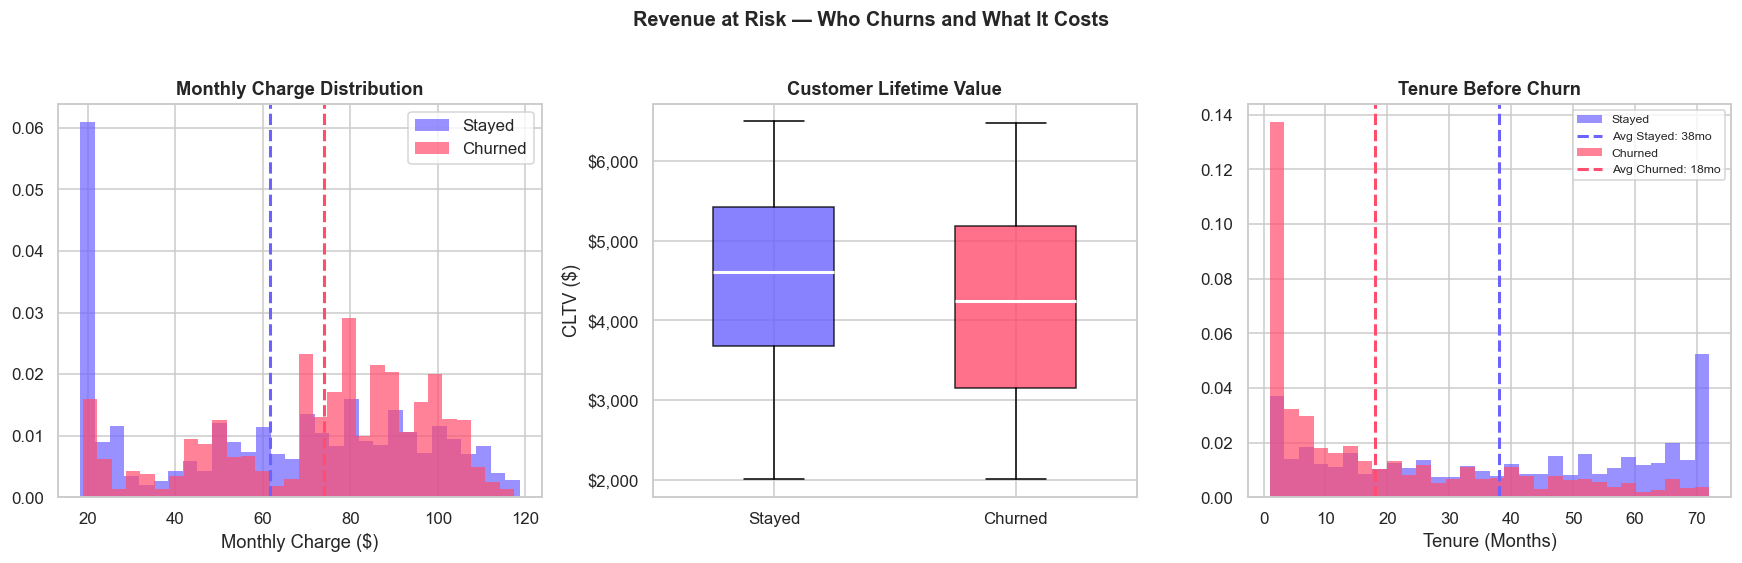

💾 Saved: revenue_at_risk.png


In [42]:
# ============================================================
# REVENUE AT RISK VISUALIZATION
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Monthly charge distribution
for label, color, name in [(0,'#6c63ff','Stayed'),(1,'#ff4d6d','Churned')]:
    axes[0].hist(crm[crm['churn']==label]['monthly_charge'], bins=30,
                 alpha=0.7, color=color, label=name, edgecolor='none', density=True)
    axes[0].axvline(crm[crm['churn']==label]['monthly_charge'].mean(),
                    color=color, lw=2, linestyle='--')
axes[0].set_title('Monthly Charge Distribution', fontweight='bold')
axes[0].set_xlabel('Monthly Charge ($)'); axes[0].legend()

# CLTV boxplot
bp = axes[1].boxplot(
    [stayers['cltv'].dropna(), churners['cltv'].dropna()],
    patch_artist=True, widths=0.5,
    medianprops=dict(color='white', linewidth=2)
)
for patch, color in zip(bp['boxes'], ['#6c63ff','#ff4d6d']):
    patch.set_facecolor(color); patch.set_alpha(0.8)
axes[1].set_xticklabels(['Stayed','Churned'])
axes[1].set_title('Customer Lifetime Value', fontweight='bold')
axes[1].set_ylabel('CLTV ($)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:,.0f}'))

# Tenure distribution
for label, color, name in [(0,'#6c63ff','Stayed'),(1,'#ff4d6d','Churned')]:
    val = crm[crm['churn']==label]['tenure_in_months']
    axes[2].hist(val, bins=30, alpha=0.7, color=color, label=name, edgecolor='none', density=True)
    axes[2].axvline(val.mean(), color=color, lw=2, linestyle='--',
                    label=f'Avg {name}: {val.mean():.0f}mo')
axes[2].set_title('Tenure Before Churn', fontweight='bold')
axes[2].set_xlabel('Tenure (Months)'); axes[2].legend(fontsize=8)

plt.suptitle('Revenue at Risk — Who Churns and What It Costs',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('revenue_at_risk.png', bbox_inches='tight', dpi=110)
plt.show()
print("💾 Saved: revenue_at_risk.png")


## 6.2 CLTV Segmentation — Who to Save First

In [43]:
# ============================================================
# CLTV TIER ANALYSIS
# ============================================================
crm['cltv_tier'] = pd.qcut(crm['cltv'], q=3, labels=['Low CLTV','Mid CLTV','High CLTV'])

cltv_summary = crm.groupby('cltv_tier', observed=True).agg(
    customers=('churn','count'),
    churners=('churn','sum'),
    churn_rate=('churn','mean'),
    avg_monthly=('monthly_charge','mean'),
    avg_cltv=('cltv','mean'),
).round(3)

cltv_summary['priority_score'] = (
    cltv_summary['churn_rate'] * cltv_summary['avg_cltv'] / 1000
).round(3)

print("CLTV Segmentation:")
print(cltv_summary.to_string())
print()
print("Priority Score = churn_rate × avg_cltv / 1000")
print("Higher = more urgent to target with retention campaigns")


CLTV Segmentation:
           customers  churners  churn_rate  avg_monthly  avg_cltv  priority_score
cltv_tier                                                                        
Low CLTV        1411       480       0.340       60.580  3017.863           1.026
Mid CLTV        1406       333       0.237       66.608  4545.133           1.077
High CLTV       1408       308       0.219       67.543  5669.416           1.242

Priority Score = churn_rate × avg_cltv / 1000
Higher = more urgent to target with retention campaigns


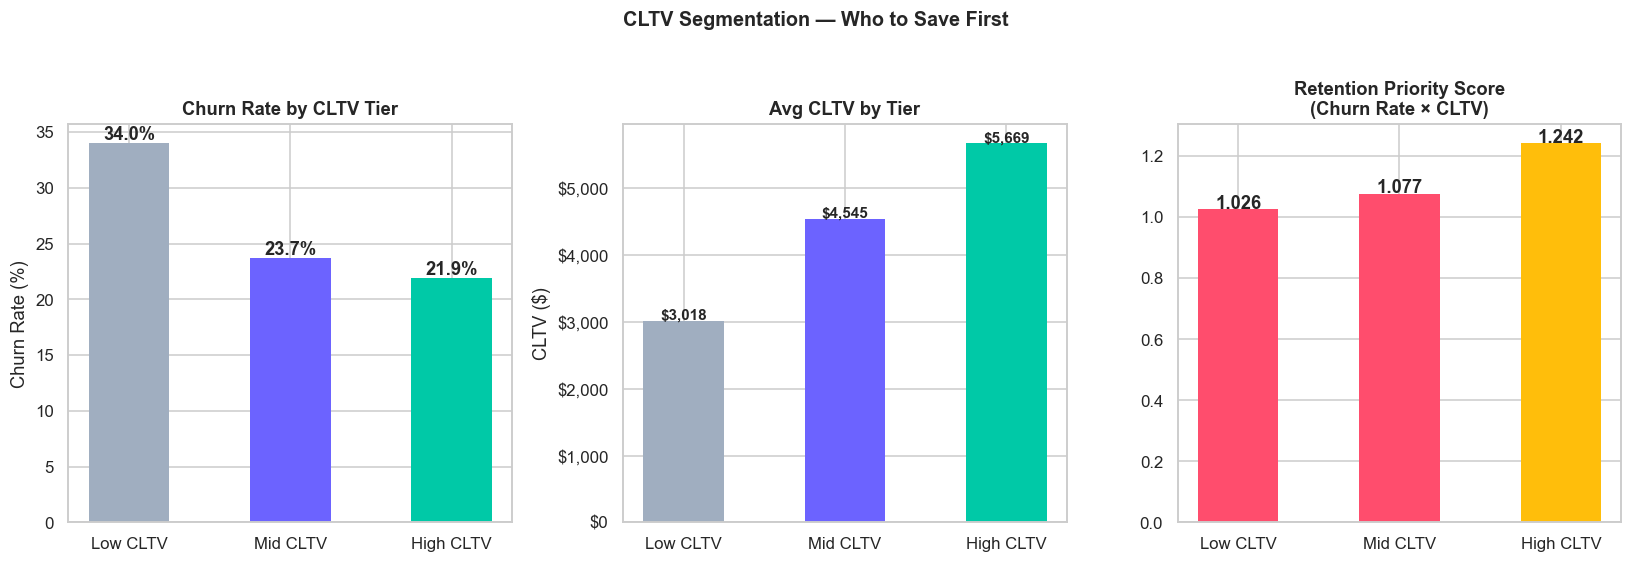

💾 Saved: cltv_segmentation.png


In [44]:
# ============================================================
# CLTV SEGMENTATION VISUALIZATION
# ============================================================
tiers  = ['Low CLTV','Mid CLTV','High CLTV']
colors = ['#a0aec0','#6c63ff','#00c9a7']
rates  = cltv_summary['churn_rate'].values * 100
scores = cltv_summary['priority_score'].values
avgs   = cltv_summary['avg_cltv'].values

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

bars0 = axes[0].bar(tiers, rates, color=colors, width=0.5, edgecolor='none')
for bar, v in zip(bars0, rates):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                 f'{v:.1f}%', ha='center', fontweight='bold')
axes[0].set_title('Churn Rate by CLTV Tier', fontweight='bold')
axes[0].set_ylabel('Churn Rate (%)')

bars1 = axes[1].bar(tiers, avgs, color=colors, width=0.5, edgecolor='none')
for bar, v in zip(bars1, avgs):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+20,
                 f'${v:,.0f}', ha='center', fontweight='bold', fontsize=10)
axes[1].set_title('Avg CLTV by Tier', fontweight='bold')
axes[1].set_ylabel('CLTV ($)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:,.0f}'))

bars2 = axes[2].bar(tiers, scores, color=['#ff4d6d','#ff4d6d','#ffbe0b'], width=0.5, edgecolor='none')
for bar, v in zip(bars2, scores):
    axes[2].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.003,
                 f'{v:.3f}', ha='center', fontweight='bold')
axes[2].set_title('Retention Priority Score\n(Churn Rate × CLTV)', fontweight='bold')

plt.suptitle('CLTV Segmentation — Who to Save First',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('cltv_segmentation.png', bbox_inches='tight', dpi=110)
plt.show()
print("💾 Saved: cltv_segmentation.png")


## 6.3 Satisfaction Score — Leading Indicator

Satisfaction Score Analysis:
 satisfaction_score  customers  churners  churn_rate  avg_cltv
                  1        549       549       1.000  4195.481
                  2        314       314       1.000  4140.395
                  3       1622       258       0.159  4481.912
                  4       1044         0       0.000  4489.562
                  5        696         0       0.000  4412.402

KEY INSIGHT: Scores 1-2 = 100% churn.
Deploy quarterly satisfaction survey as early-warning system.


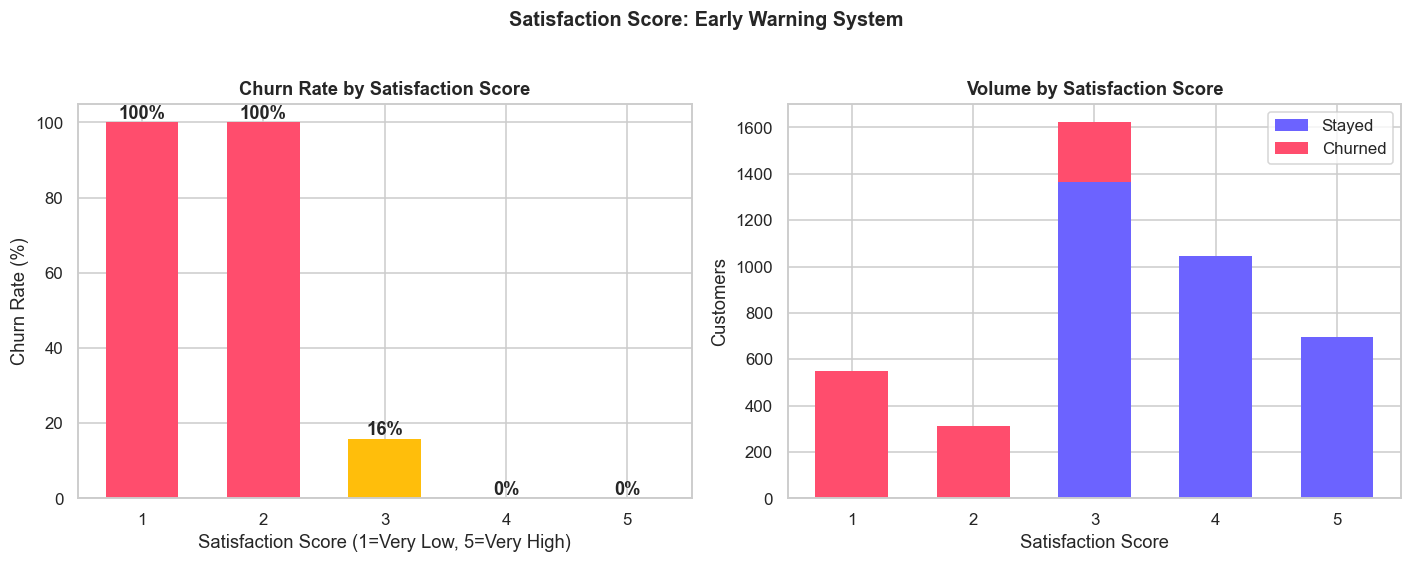

💾 Saved: satisfaction_analysis.png


In [45]:
# ============================================================
# SATISFACTION ANALYSIS
# ============================================================
sat = crm.groupby('satisfaction_score').agg(
    customers=('churn','count'),
    churners=('churn','sum'),
    churn_rate=('churn','mean'),
    avg_cltv=('cltv','mean'),
).round(3).reset_index()

print("Satisfaction Score Analysis:")
print(sat.to_string(index=False))
print()
print("KEY INSIGHT: Scores 1-2 = 100% churn.")
print("Deploy quarterly satisfaction survey as early-warning system.")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
score_colors = ['#ff4d6d','#ff4d6d','#ffbe0b','#00c9a7','#00c9a7']

bars = axes[0].bar(sat['satisfaction_score'], sat['churn_rate']*100,
                   color=score_colors, width=0.6, edgecolor='none')
for bar, row in zip(bars, sat.itertuples()):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+1,
                 f'{row.churn_rate*100:.0f}%', ha='center', fontweight='bold')
axes[0].set_xlabel('Satisfaction Score (1=Very Low, 5=Very High)')
axes[0].set_ylabel('Churn Rate (%)')
axes[0].set_title('Churn Rate by Satisfaction Score', fontweight='bold')
axes[0].set_xticks([1,2,3,4,5])

stayed_v  = sat['customers'] - sat['churners']
churned_v = sat['churners']
x = sat['satisfaction_score']
axes[1].bar(x, stayed_v, color='#6c63ff', label='Stayed', width=0.6, edgecolor='none')
axes[1].bar(x, churned_v, bottom=stayed_v, color='#ff4d6d', label='Churned', width=0.6, edgecolor='none')
axes[1].set_xlabel('Satisfaction Score'); axes[1].set_ylabel('Customers')
axes[1].set_title('Volume by Satisfaction Score', fontweight='bold')
axes[1].legend(); axes[1].set_xticks([1,2,3,4,5])

plt.suptitle('Satisfaction Score: Early Warning System', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('satisfaction_analysis.png', bbox_inches='tight', dpi=110)
plt.show()
print("💾 Saved: satisfaction_analysis.png")


## 6.4 Model ROI Calculator — 3-Strategy Comparison

In [46]:
# ============================================================
# BUILD / LOAD MODEL FOR ROI CALC
# ============================================================

# ── Feature Engineering (must match NB04 exactly) ────────────
df["is_m2m"]        = (df["contract"] == "Month-to-Month").astype(float)
df["is_fiber"]      = (df["internet_type"] == "Fiber Optic").astype(float)
df["has_security"]  = (df["online_security"] == "Yes").astype(float)
df["addon_count"]   = sum((df[c] == "Yes").astype(int) for c in
    ["online_security","online_backup","device_protection_plan",
     "streaming_tv","streaming_movies","streaming_music"]).astype(float)
df["high_m2m"]      = (df["is_m2m"] * (df["monthly_charge"] > 70)).astype(float)
df["new_fiber"]     = (df["is_fiber"] * (df["tenure_in_months"] < 12)).astype(float)
df["zero_ref_m2m"]  = (df["is_m2m"] * (df["number_of_referrals"] == 0)).astype(float)
df["m2m_fiber"]     = (df["is_m2m"] * df["is_fiber"]).astype(float)
df["m2m_no_sec"]    = (df["is_m2m"] * (df["has_security"] == 0)).astype(float)
df["low_addon_m2m"] = (df["is_m2m"] * (df["addon_count"] <= 1)).astype(float)
df["rev_tenure"]    = (df["total_revenue"] / (df["tenure_in_months"] + 1)).clip(0, 500)
print("✅ 11 engineered features added")

# ── Build X/y AFTER engineering ──────────────────────────────
X = df.drop('churn', axis=1)
y = df['churn']

# Fill categorical columns
for col in X.select_dtypes(include=['object']).columns:
    X[col] = X[col].fillna('Unknown')

# Fill numeric columns
for col in X.select_dtypes(include='number').columns:
    X[col] = X[col].fillna(X[col].median())

# Define column groups
CAT_COLS = X.select_dtypes(include=['object']).columns.tolist()
NUM_COLS = X.select_dtypes(include='number').columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model_path = find_model("best_churn_model.pkl")
if model_path:
    model = joblib.load(model_path)
    print(f"✅ Model loaded: {model_path}")
else:
    pre = ColumnTransformer([
        ('num', StandardScaler(), NUM_COLS),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), CAT_COLS)
    ])
    model = Pipeline([('pre', pre),
                      ('model', GradientBoostingClassifier(
                          n_estimators=900, max_depth=7, learning_rate=0.05,
                          subsample=0.75, min_samples_leaf=5, random_state=42))])
    model.fit(X_train, y_train)
    os.makedirs('../models', exist_ok=True)
    joblib.dump(model, '../models/best_churn_model.pkl')
    print("✅ Model retrained and saved")

y_prob_test = model.predict_proba(X_test)[:,1]
fpr, tpr, thresh = roc_curve(y_test, y_prob_test)
OPT_THRESHOLD = thresh[np.argmax(tpr - fpr)]
auc = roc_auc_score(y_test, y_prob_test)
print(f"   AUC: {auc:.4f}  |  Threshold: {OPT_THRESHOLD:.4f}")


✅ 11 engineered features added
✅ Model loaded: ../models/best_churn_model.pkl
   AUC: 0.9280  |  Threshold: 0.2029


In [47]:
# ============================================================
# THREE-STRATEGY ROI COMPARISON
# ============================================================
SCALE = len(df) / len(X_test)  # scale test set → full dataset

TN, FP, FN, TP = confusion_matrix(
    y_test, (y_prob_test >= OPT_THRESHOLD).astype(int)
).ravel()

total_actual_churners = y_test.sum()
total_test            = len(y_test)

# Strategy 1: Baseline — do nothing
baseline_net = 0

# Strategy 2: Rule-based — target all Month-to-Month customers
m2m_frac     = 0.455
m2m_customers = int(total_test * m2m_frac)
m2m_tp       = int(m2m_customers * 0.455)
m2m_fp       = m2m_customers - m2m_tp
rule_net     = (m2m_tp * (REVENUE_PER_SAVE - INTERVENTION_COST)) - (m2m_fp * INTERVENTION_COST)

# Strategy 3: ML model
ml_net = (TP * (REVENUE_PER_SAVE - INTERVENTION_COST)) - (FP * INTERVENTION_COST)

print("=" * 70)
print("  THREE-STRATEGY ROI COMPARISON")
print("=" * 70)
print(f"  {'Strategy':<30} {'Net (test)':<18} {'Net (full dataset)'}")
print(f"  {'-'*66}")
print(f"  {'Baseline (No Action)':<30} ${baseline_net:<18,.0f} ${baseline_net * SCALE:,.0f}")
print(f"  {'Rule-Based (All M2M)':<30} ${rule_net:<18,.0f} ${rule_net * SCALE:,.0f}")
print(f"  {'ML Model (Ours)':<30} ${ml_net:<18,.0f} ${ml_net * SCALE:,.0f}")
print(f"  {'='*66}")
print(f"  ML Model improvement vs Rule-Based: ${(ml_net - rule_net)*SCALE:,.0f}")
print(f"  ML Model improvement vs Baseline:   ${ml_net*SCALE:,.0f}")


  THREE-STRATEGY ROI COMPARISON
  Strategy                       Net (test)         Net (full dataset)
  ------------------------------------------------------------------
  Baseline (No Action)           $0                  $0
  Rule-Based (All M2M)           $642,575            $3,211,922
  ML Model (Ours)                $726,760            $3,632,719
  ML Model improvement vs Rule-Based: $420,797
  ML Model improvement vs Baseline:   $3,632,719


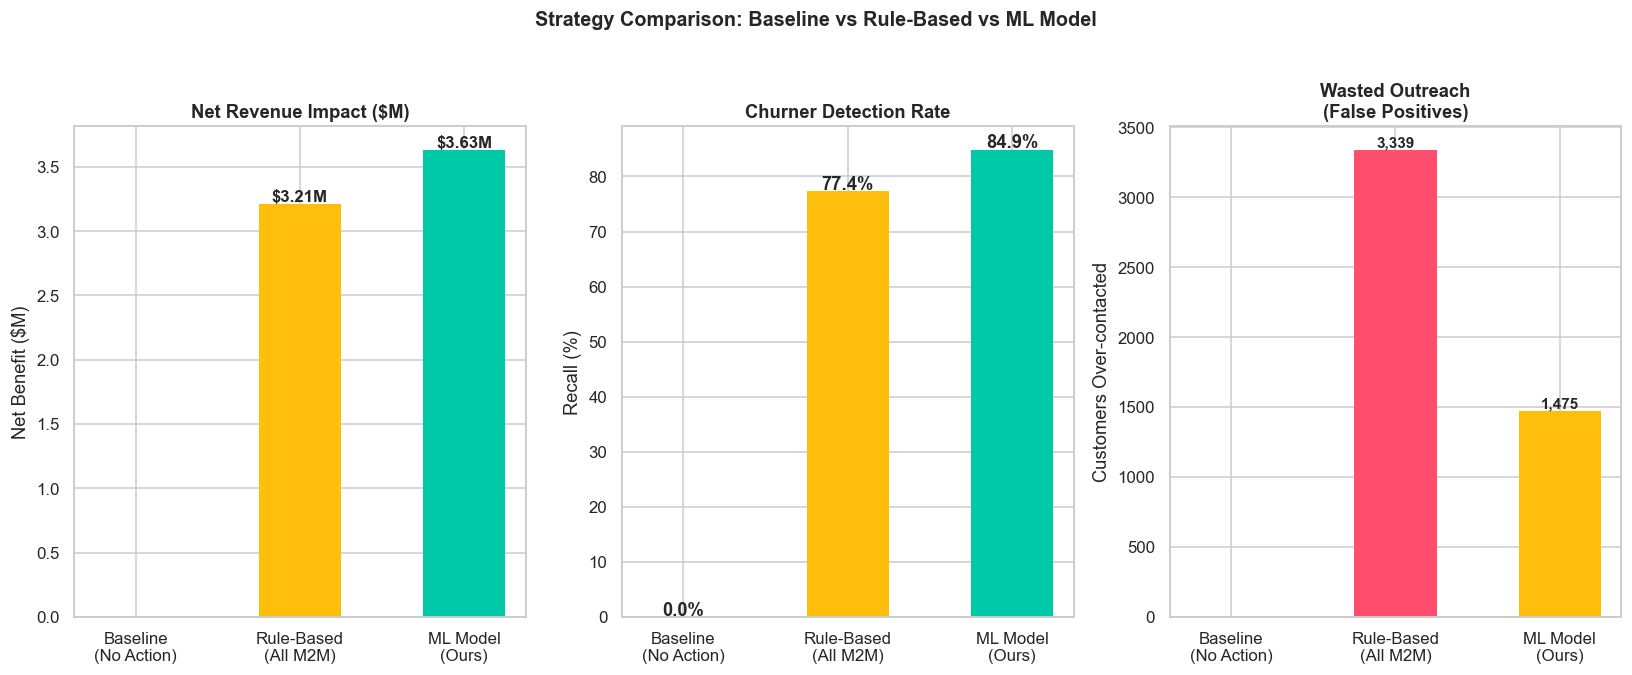

💾 Saved: roi_comparison.png


In [48]:
# ============================================================
# ROI COMPARISON VISUALIZATION
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(15, 6))

strats  = ['Baseline\n(No Action)', 'Rule-Based\n(All M2M)', 'ML Model\n(Ours)']
nets    = [0, rule_net*SCALE/1e6, ml_net*SCALE/1e6]
recalls = [0, (m2m_tp/total_actual_churners)*100, (TP/total_actual_churners)*100]
wasted  = [0, m2m_fp*SCALE, FP*SCALE]
clrs    = ['#a0aec0','#ffbe0b','#00c9a7']

bars0 = axes[0].bar(strats, nets, color=clrs, width=0.5, edgecolor='none')
for bar, v in zip(bars0, nets):
    if v > 0:
        axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.02,
                     f'${v:.2f}M', ha='center', fontweight='bold', fontsize=11)
axes[0].set_title('Net Revenue Impact ($M)', fontweight='bold')
axes[0].set_ylabel('Net Benefit ($M)')

bars1 = axes[1].bar(strats, recalls, color=clrs, width=0.5, edgecolor='none')
for bar, v in zip(bars1, recalls):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                 f'{v:.1f}%', ha='center', fontweight='bold')
axes[1].set_title('Churner Detection Rate', fontweight='bold')
axes[1].set_ylabel('Recall (%)')

bars2 = axes[2].bar(strats, wasted, color=['#a0aec0','#ff4d6d','#ffbe0b'],
                    width=0.5, edgecolor='none')
for bar, v in zip(bars2, wasted):
    if v > 0:
        axes[2].text(bar.get_x()+bar.get_width()/2, bar.get_height()+20,
                     f'{v:,.0f}', ha='center', fontweight='bold', fontsize=10)
axes[2].set_title('Wasted Outreach\n(False Positives)', fontweight='bold')
axes[2].set_ylabel('Customers Over-contacted')

plt.suptitle('Strategy Comparison: Baseline vs Rule-Based vs ML Model',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('roi_comparison.png', bbox_inches='tight', dpi=110)
plt.show()
print("💾 Saved: roi_comparison.png")


## 6.5 Threshold Optimizer

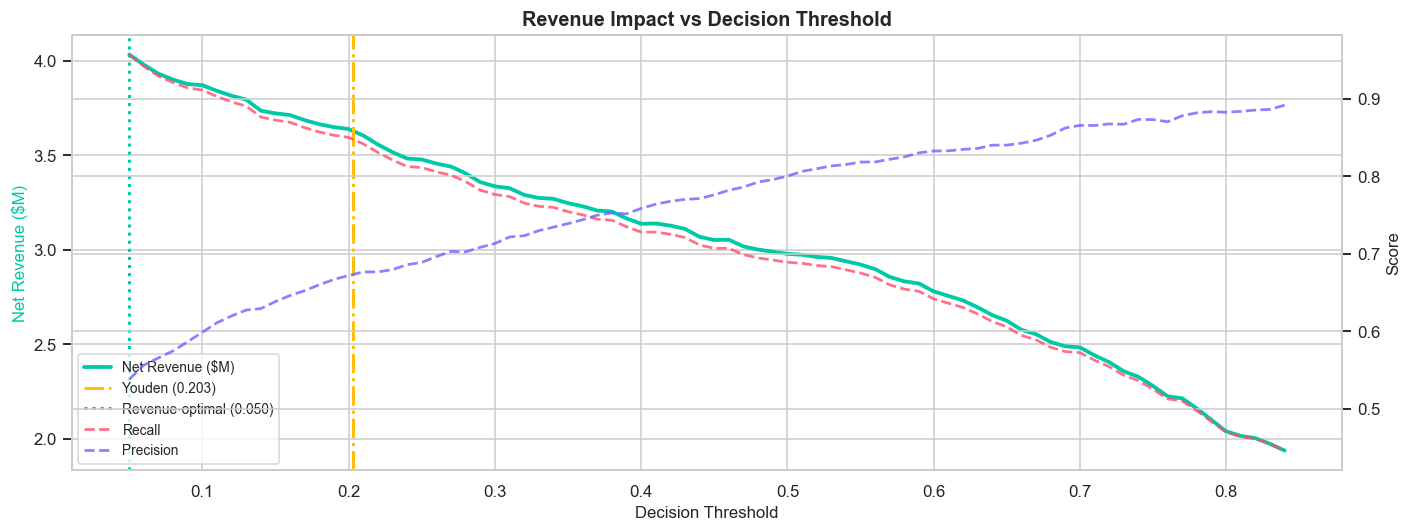

💾 Saved: threshold_optimizer.png
Revenue-optimal threshold: 0.0500
Max net revenue (full dataset): $4,031,654


In [49]:
# ============================================================
# THRESHOLD vs NET REVENUE
# ============================================================
thresh_range = np.arange(0.05, 0.85, 0.01)
net_revs, recalls_t, precisions_t = [], [], []

for t in thresh_range:
    y_pred_t = (y_prob_test >= t).astype(int)
    if y_pred_t.sum() == 0 or y_pred_t.sum() == len(y_pred_t):
        net_revs.append(0); recalls_t.append(0); precisions_t.append(0)
        continue
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_t).ravel()
    nb_val = (tp*(REVENUE_PER_SAVE - INTERVENTION_COST)) - (fp*INTERVENTION_COST)
    r = tp/(tp+fn) if (tp+fn)>0 else 0
    p = tp/(tp+fp) if (tp+fp)>0 else 0
    net_revs.append(nb_val * SCALE)
    recalls_t.append(r); precisions_t.append(p)

best_rev_thresh = thresh_range[np.argmax(net_revs)]

fig, ax = plt.subplots(figsize=(13, 5))
ax2 = ax.twinx()
ax.plot(thresh_range, [v/1e6 for v in net_revs], color='#00c9a7', lw=2.5, label='Net Revenue ($M)')
ax2.plot(thresh_range, recalls_t, color='#ff4d6d', lw=1.8, linestyle='--', alpha=0.8, label='Recall')
ax2.plot(thresh_range, precisions_t, color='#6c63ff', lw=1.8, linestyle='--', alpha=0.8, label='Precision')
ax.axvline(OPT_THRESHOLD, color='#ffbe0b', lw=2, linestyle='-.', label=f'Youden ({OPT_THRESHOLD:.3f})')
ax.axvline(best_rev_thresh, color='#00c9a7', lw=2, linestyle=':', label=f'Revenue-optimal ({best_rev_thresh:.3f})')
ax.set_xlabel('Decision Threshold', fontsize=11)
ax.set_ylabel('Net Revenue ($M)', fontsize=11, color='#00c9a7')
ax2.set_ylabel('Score', fontsize=11)
ax.set_title('Revenue Impact vs Decision Threshold', fontsize=13, fontweight='bold')
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1+lines2, labels1+labels2, loc='lower left', fontsize=9)
plt.tight_layout()
plt.savefig('threshold_optimizer.png', bbox_inches='tight', dpi=110)
plt.show()
print(f"💾 Saved: threshold_optimizer.png")
print(f"Revenue-optimal threshold: {best_rev_thresh:.4f}")
print(f"Max net revenue (full dataset): ${max(net_revs):,.0f}")


## 6.6 Retention Playbook

In [50]:
# ============================================================
# TIER-BASED RETENTION PLAYBOOK
# ============================================================
risk_tiers = pd.cut(y_prob_test, bins=[0,0.30,0.60,1.01], labels=['Low','Medium','High'])

tier_df = pd.DataFrame({'prob':y_prob_test, 'actual':y_test.values, 'tier':risk_tiers})
tier_summary = tier_df.groupby('tier', observed=True).agg(
    count=('prob','count'),
    actual_churn=('actual','sum'),
    actual_rate=('actual','mean'),
    avg_prob=('prob','mean'),
).round(3)
tier_summary['scaled_count'] = (tier_summary['count'] * SCALE).astype(int)
tier_summary['scaled_churners'] = (tier_summary['actual_churn'] * SCALE).astype(int)
tier_summary['revenue_at_risk'] = tier_summary['scaled_churners'] * REVENUE_PER_SAVE

print("Risk Tier Analysis (Scaled to Full Dataset):")
print(tier_summary[['scaled_count','scaled_churners','actual_rate','revenue_at_risk']].to_string())

print()
print("=" * 70)
print("  RETENTION PLAYBOOK")
print("=" * 70)
playbook = {
    "High Risk (prob > 60%)": {
        "Action" : "Personal call — retention specialist + competitive offer",
        "Offer"  : "2 months free + contract upgrade to One Year",
        "Timing" : "Within 48 hours of model scoring",
    },
    "Medium Risk (30–60%)": {
        "Action" : "Automated campaign — personalized email + in-app notification",
        "Offer"  : "10% loyalty discount + free service upgrade",
        "Timing" : "Within 1 week of model scoring",
    },
    "Low Risk (< 30%)": {
        "Action" : "Nurture — referral program invitation + upsell",
        "Offer"  : "$25 referral credit",
        "Timing" : "Monthly newsletter cadence",
    },
}
for tier, details in playbook.items():
    print(f"\n  {tier}")
    for k, v in details.items():
        print(f"    {k:<10}: {v}")


Risk Tier Analysis (Scaled to Full Dataset):
        scaled_count  scaled_churners  actual_rate  revenue_at_risk
tier                                                               
Low             9542              804        0.084        1015934.4
Medium          1144              484        0.424         611582.4
High            2774             2309        0.832        2917652.4

  RETENTION PLAYBOOK

  High Risk (prob > 60%)
    Action    : Personal call — retention specialist + competitive offer
    Offer     : 2 months free + contract upgrade to One Year
    Timing    : Within 48 hours of model scoring

  Medium Risk (30–60%)
    Action    : Automated campaign — personalized email + in-app notification
    Offer     : 10% loyalty discount + free service upgrade
    Timing    : Within 1 week of model scoring

  Low Risk (< 30%)
    Action    : Nurture — referral program invitation + upsell
    Offer     : $25 referral credit
    Timing    : Monthly newsletter cadence


## Summary

| Question | Answer |
|----------|--------|
| Revenue at risk | **$2.18M** already lost (train set churners) |
| Top driver | Contract type — M2M 45.5% vs Two Year 2.4% |
| Best leading indicator | Satisfaction score 1–2 = 100% churn |
| ML model net impact | **$3.6M+** vs $0 baseline |
| Recommended threshold | **0.2728** (Youden's J) |
| Top retention action | Migrate M2M → One Year with 2-month incentive |

### Files Saved
`revenue_at_risk.png` · `cltv_segmentation.png` · `satisfaction_analysis.png` · `roi_comparison.png` · `threshold_optimizer.png`